# Cluster Analysis — 20 Newsgroups Fuzzy C-Means

This notebook visualises the clustering artefacts produced by the FCM pipeline.

**Artefacts loaded from** `artefacts/clustering/`:
- `membership_matrix.npy` — (17151, 8) fuzzy memberships
- `cluster_centers.npy` — (8, 50) PCA-space centroids
- `pca_model.pkl` — fitted PCA transformer
- `embeddings.npy` — (17151, 384) raw embeddings
- `fcm_meta.json` — sweep results, selected c, metrics

In [1]:
import json, os
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
import chromadb

# Style
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='deep')

# Paths
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
ARTEFACT_DIR = os.path.join(PROJECT_ROOT, 'artefacts', 'clustering')
CHROMA_DIR   = os.path.join(PROJECT_ROOT, 'artefacts', 'chroma_db')

# Load artefacts
U        = np.load(os.path.join(ARTEFACT_DIR, 'membership_matrix.npy'))
centers  = np.load(os.path.join(ARTEFACT_DIR, 'cluster_centers.npy'))
emb      = np.load(os.path.join(ARTEFACT_DIR, 'embeddings.npy'))
pca      = joblib.load(os.path.join(ARTEFACT_DIR, 'pca_model.pkl'))

with open(os.path.join(ARTEFACT_DIR, 'fcm_meta.json')) as f:
    meta = json.load(f)

with open(os.path.join(ARTEFACT_DIR, 'doc_id_order.json')) as f:
    doc_ids = json.load(f)

# Load ChromaDB for document text
client     = chromadb.PersistentClient(path=CHROMA_DIR)
collection = client.get_collection('newsgroups_v1')

# Load original dataset for labels
dataset = fetch_20newsgroups(subset='all', remove=())
label_names = dataset.target_names

print(f"Membership matrix: {U.shape}")
print(f"Clusters: {meta['c']}, fuzzifier m={meta['m']}")
print(f"PC={meta['pc_score']:.4f}, XB={meta['xb_score']:.1f}")
print(f"Loaded {len(doc_ids)} document IDs")

/home/aditya/Desktop/Trademarkia/twenty_newsgroups_semantic_search/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.4.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given


Membership matrix: (17151, 8)
Clusters: 8, fuzzifier m=1.2
PC=0.2443, XB=78975.1
Loaded 17151 document IDs


## 1. Top-10 TF-IDF Terms per Cluster
For each cluster, select documents where membership > 0.3, then extract the most distinctive terms.

In [2]:
# Fetch all document texts
all_results = collection.get(ids=doc_ids, include=['documents', 'metadatas'])
doc_texts = {did: txt for did, txt in zip(all_results['ids'], all_results['documents'])}
doc_labels = {did: m.get('original_label', '?') for did, m in zip(all_results['ids'], all_results['metadatas'])}

# Map doc_ids index to text
ordered_texts = [doc_texts.get(did, '') for did in doc_ids]
ordered_labels = [doc_labels.get(did, '?') for did in doc_ids]

n_clusters = U.shape[1]

print("=" * 70)
print("TOP-10 TF-IDF TERMS PER CLUSTER (membership > 0.3)")
print("=" * 70)

for k in range(n_clusters):
    mask = U[:, k] > 0.3
    cluster_docs = [ordered_texts[i] for i in range(len(ordered_texts)) if mask[i]]
    n_docs = len(cluster_docs)
    
    if n_docs < 5:
        print(f"\nCluster {k}: only {n_docs} docs with membership > 0.3 — skipping TF-IDF")
        continue
    
    tfidf = TfidfVectorizer(max_features=5000, stop_words='english', max_df=0.8, min_df=3)
    X = tfidf.fit_transform(cluster_docs)
    mean_tfidf = X.mean(axis=0).A1
    top_idx = mean_tfidf.argsort()[-10:][::-1]
    terms = tfidf.get_feature_names_out()
    top_terms = [(terms[i], round(mean_tfidf[i], 4)) for i in top_idx]
    
    print(f"\nCluster {k} ({n_docs} docs): {', '.join(t[0] for t in top_terms)}")
    for term, score in top_terms:
        print(f"  {term:20s}  {score:.4f}")

Failed to send telemetry event CollectionGetEvent: capture() takes 1 positional argument but 3 were given


TOP-10 TF-IDF TERMS PER CLUSTER (membership > 0.3)



Cluster 0 (1806 docs): people, writes, article, government, don, gun, just, like, think, fbi
  people                0.0263
  writes                0.0260
  article               0.0256
  government            0.0214
  don                   0.0208
  gun                   0.0187
  just                  0.0178
  like                  0.0175
  think                 0.0166
  fbi                   0.0162

Cluster 1: only 0 docs with membership > 0.3 — skipping TF-IDF

Cluster 2: only 0 docs with membership > 0.3 — skipping TF-IDF

Cluster 3: only 0 docs with membership > 0.3 — skipping TF-IDF



Cluster 4 (1990 docs): god, writes, people, article, jesus, don, christian, think, say, just
  god                   0.0410
  writes                0.0244
  people                0.0239
  article               0.0220
  jesus                 0.0218
  don                   0.0211
  christian             0.0195
  think                 0.0191
  say                   0.0187
  just                  0.0178

Cluster 5 (1348 docs): card, know, drive, windows, pc, video, like, software, does, use
  card                  0.0291
  know                  0.0194
  drive                 0.0192
  windows               0.0192
  pc                    0.0180
  video                 0.0179
  like                  0.0177
  software              0.0175
  does                  0.0167
  use                   0.0159

Cluster 6: only 0 docs with membership > 0.3 — skipping TF-IDF



Cluster 7 (1616 docs): game, writes, team, article, year, don, games, hockey, think, like
  game                  0.0290
  writes                0.0238
  team                  0.0238
  article               0.0219
  year                  0.0206
  don                   0.0197
  games                 0.0195
  hockey                0.0191
  think                 0.0185
  like                  0.0165


## 2. Most Representative Documents per Cluster
The 3 documents with the highest membership in each cluster.

In [3]:
print("=" * 70)
print("3 MOST REPRESENTATIVE DOCUMENTS PER CLUSTER")
print("=" * 70)

for k in range(n_clusters):
    top3_idx = U[:, k].argsort()[-3:][::-1]
    print(f"\n--- Cluster {k} ---")
    for rank, idx in enumerate(top3_idx):
        did = doc_ids[idx]
        text = doc_texts.get(did, 'N/A')[:200]
        label = doc_labels.get(did, '?')
        u_val = U[idx, k]
        print(f"  #{rank+1} (u={u_val:.4f}, label={label})")
        print(f"    {text}...")
        print()

3 MOST REPRESENTATIVE DOCUMENTS PER CLUSTER

--- Cluster 0 ---
  #1 (u=0.7291, label=talk.politics.guns)
    Subject: Blast them next time

In article (Daniel Oldham) writes:

Well, it's said that people get the government they deserve.

Don't worry, you'll get yours. You'll sleep much better when
everyone w...

  #2 (u=0.6708, label=talk.politics.guns)
    Subject: A Scoop of Waco Road, Please

(C. D. Tavares) writes:

Even though I find this to be funny on the surface, the original poster of the
joke has tried and convicted the members of the BD to be ...

  #3 (u=0.6277, label=talk.politics.guns)
    Subject: BD's did themselves--you're all paranoid freaks

In article (Jim De

Go to hell. I'm no "government [-] following fanatic." Your sweeping
generalizations evince your own ignorance. What were ...


--- Cluster 1 ---
  #1 (u=0.2226, label=rec.autos)
    Subject: Necessity of fuel injector cleaning by dealership

In article (paul.r.mount) writes:

A "fuel injector cleaning" at the

## 3. Boundary Documents (max membership < 0.20)
Documents that genuinely sit between clusters — the most semantically ambiguous posts.

In [4]:
max_u = U.max(axis=1)
boundary_mask = max_u < 0.20
boundary_idx = np.where(boundary_mask)[0]
sorted_boundary = boundary_idx[max_u[boundary_idx].argsort()]

print(f"Total boundary docs (max_u < 0.20): {len(boundary_idx)} / {len(U)} ({len(boundary_idx)/len(U)*100:.1f}%)")
print("=" * 70)
print("5 MOST AMBIGUOUS BOUNDARY DOCUMENTS")
print("=" * 70)

for rank, idx in enumerate(sorted_boundary[:5]):
    did = doc_ids[idx]
    text = doc_texts.get(did, 'N/A')[:250]
    label = doc_labels.get(did, '?')
    top3 = U[idx].argsort()[-3:][::-1]
    mem_str = ', '.join([f'c{c}={U[idx,c]:.3f}' for c in top3])
    
    print(f"\n--- Boundary Doc #{rank+1} (max_u={max_u[idx]:.4f}) ---")
    print(f"  Original label: {label}")
    print(f"  Top memberships: {mem_str}")
    print(f"  Text: {text}...")

Total boundary docs (max_u < 0.20): 5613 / 17151 (32.7%)
5 MOST AMBIGUOUS BOUNDARY DOCUMENTS

--- Boundary Doc #1 (max_u=0.1513) ---
  Original label: soc.religion.christian
  Top memberships: c4=0.151, c1=0.144, c3=0.140
  Text: Subject: Boston Church

(Dear Moderator: Would you add this to the BCC faq?)

In case there are any ex-members of the "Boston Church of Christ"
looking for a support organization, here's the number of "BostonEX" in
Burlington, MA: 617-272-1955.

s.r....

--- Boundary Doc #2 (max_u=0.1527) ---
  Original label: sci.med
  Top memberships: c1=0.153, c7=0.147, c4=0.138
  Text: Subject: Krillean Photography

In article (Alexander P. Zijdenbos) writes:


 Columbus was indeed a crank, but not in the manner you think.

 The fact that the world was round was well known when he set sail. It was
 also well known that the circumfe...

--- Boundary Doc #3 (max_u=0.1531) ---
  Original label: talk.politics.misc
  Top memberships: c4=0.153, c1=0.149, c0=0.146
  Text: Subject

## 4. Cross-Label Heatmap
Rows = 20 newsgroup categories, Columns = 8 fuzzy clusters.  
Values = mean membership of all documents from that category in each cluster.

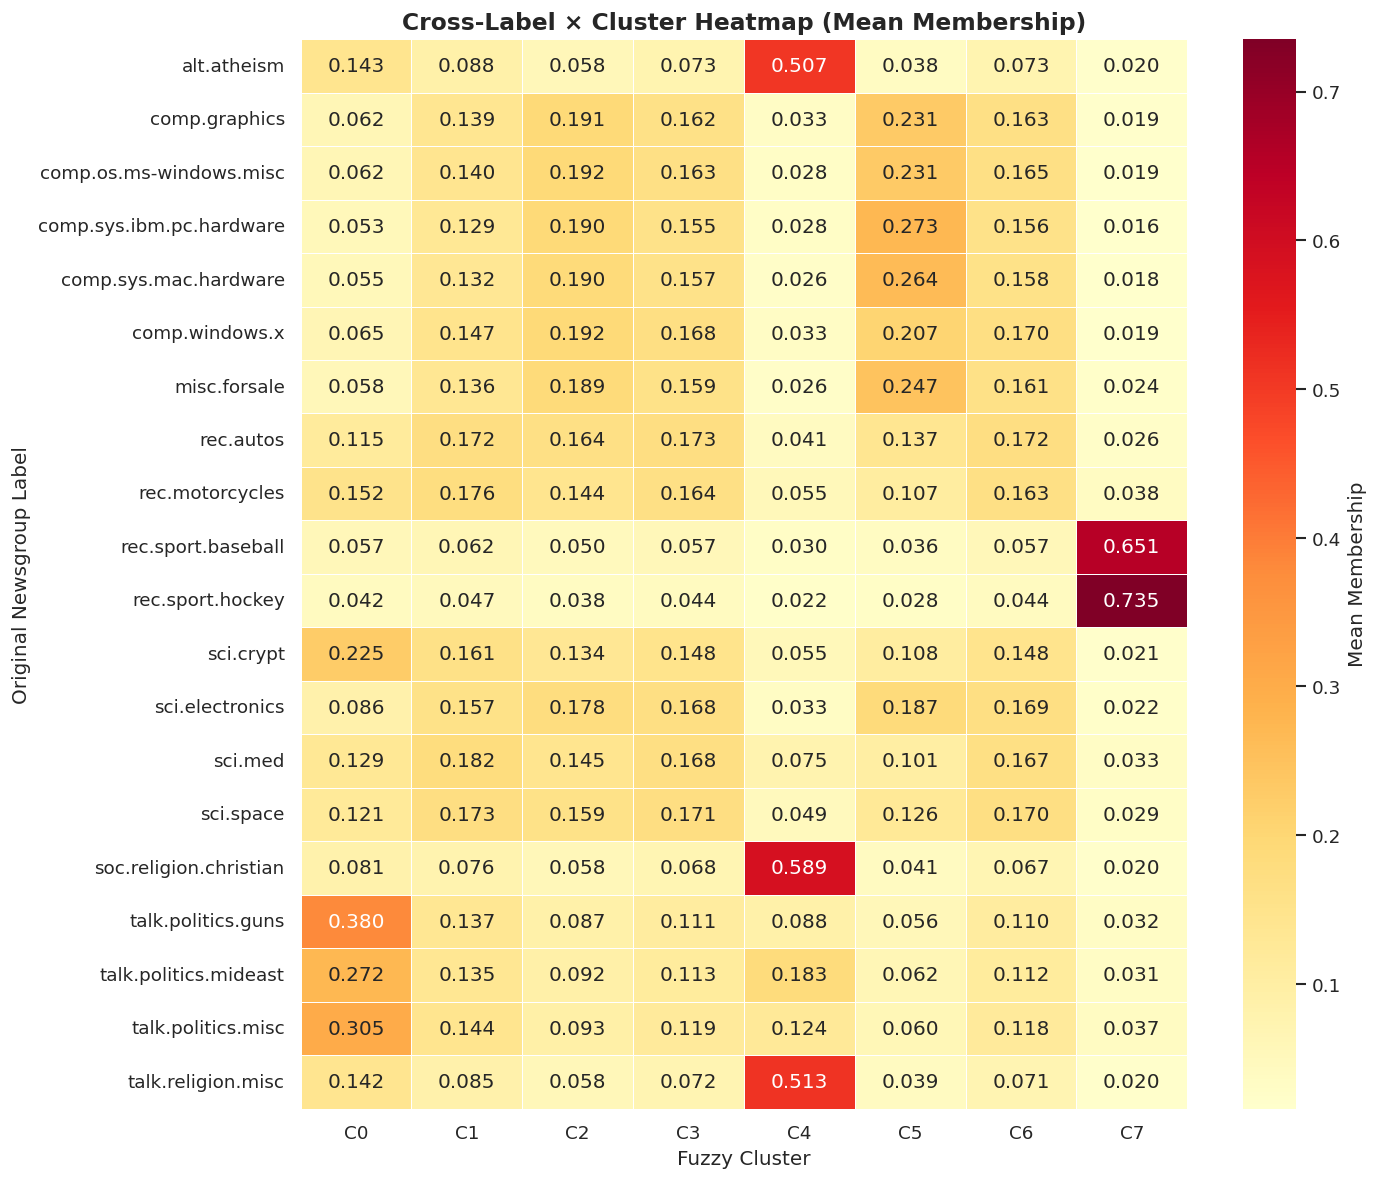

Saved to artefacts/clustering/cross_label_heatmap.png


In [5]:
# Build heatmap: (20 labels × 8 clusters)
unique_labels = sorted(set(ordered_labels))
heatmap = np.zeros((len(unique_labels), n_clusters))

for i, label in enumerate(unique_labels):
    label_mask = np.array([l == label for l in ordered_labels])
    if label_mask.sum() > 0:
        heatmap[i] = U[label_mask].mean(axis=0)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    heatmap, 
    xticklabels=[f'C{i}' for i in range(n_clusters)],
    yticklabels=unique_labels,
    annot=True, fmt='.3f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Mean Membership'},
    ax=ax
)
ax.set_title('Cross-Label × Cluster Heatmap (Mean Membership)', fontsize=14, fontweight='bold')
ax.set_xlabel('Fuzzy Cluster', fontsize=12)
ax.set_ylabel('Original Newsgroup Label', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(ARTEFACT_DIR, 'cross_label_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved to artefacts/clustering/cross_label_heatmap.png")

## 5. UMAP 2D Scatter
Each document projected to 2D via UMAP. Colour = dominant cluster, marker size ∝ max membership.

Running UMAP on 17,151 × 50 PCA embeddings (this may take 1-2 minutes)...


/home/aditya/Desktop/Trademarkia/twenty_newsgroups_semantic_search/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


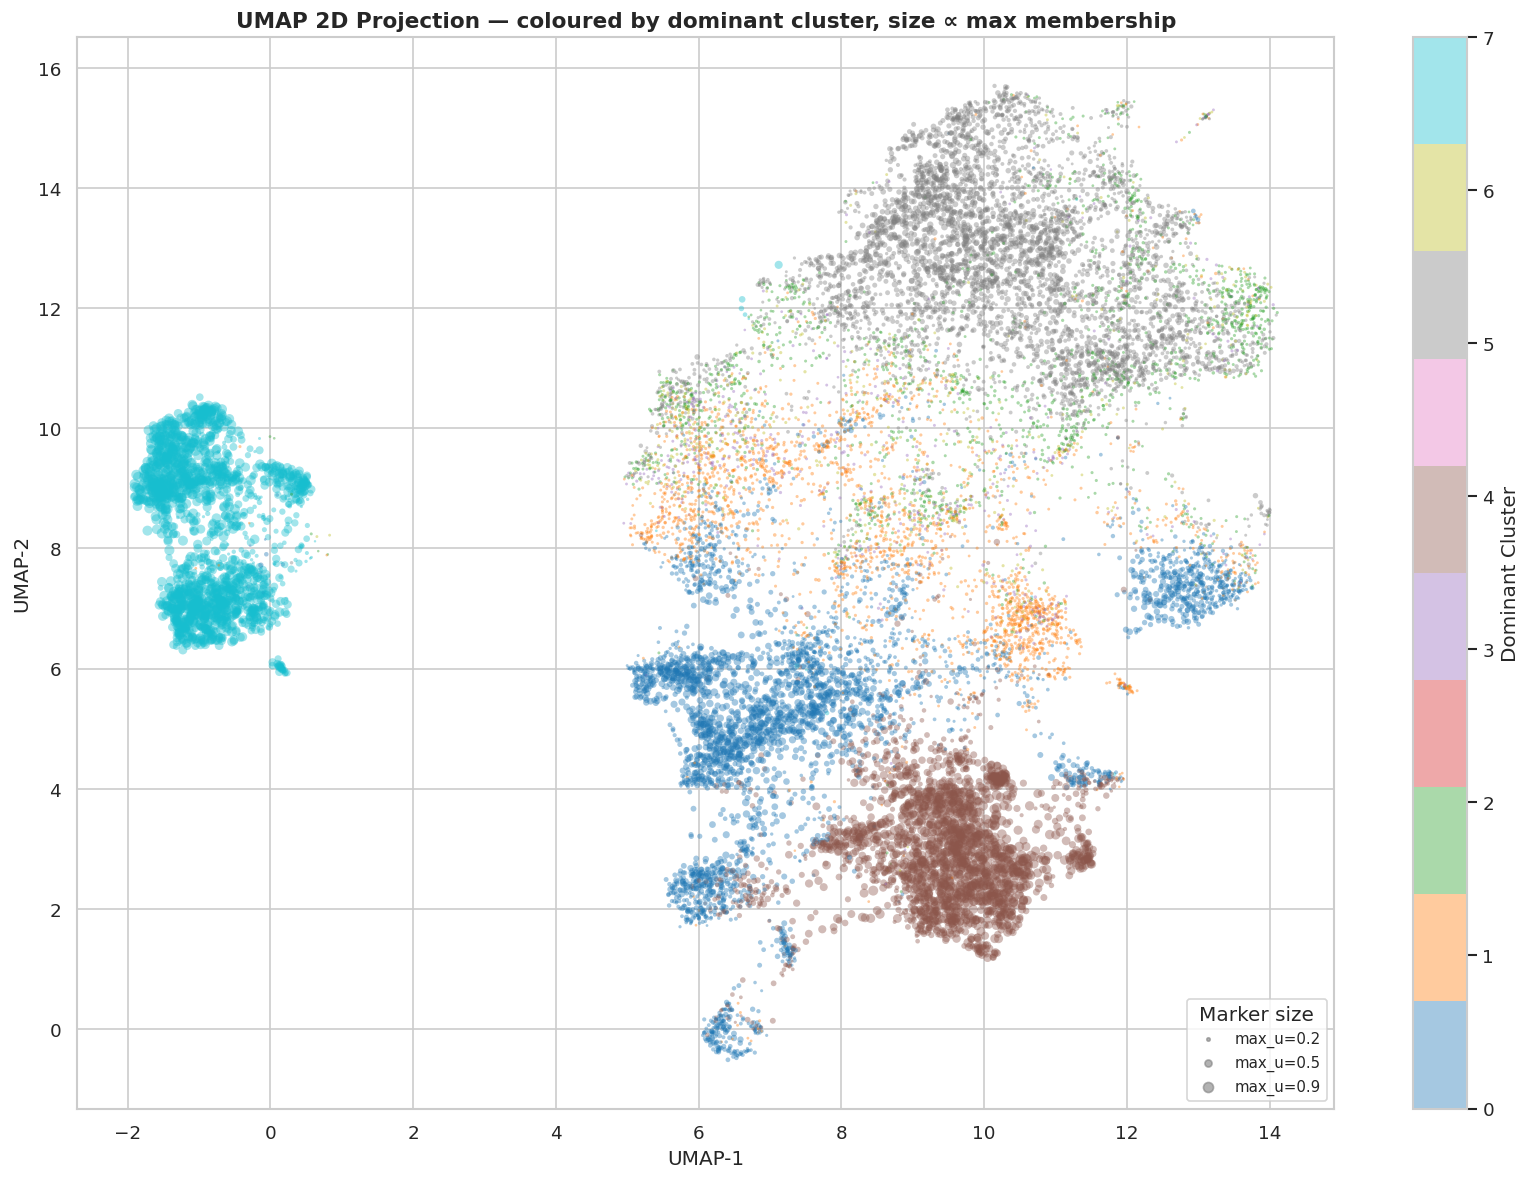

Saved to artefacts/clustering/umap_scatter.png


In [6]:
import umap

print("Running UMAP on 17,151 × 50 PCA embeddings (this may take 1-2 minutes)...")
emb_pca = pca.transform(emb)

reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.3, metric='euclidean', random_state=42)
emb_2d = reducer.fit_transform(emb_pca)

dominant_cluster = U.argmax(axis=1)
max_membership = U.max(axis=1)

# Scale marker sizes: min=2, max=40
sizes = 2 + 38 * (max_membership - max_membership.min()) / (max_membership.max() - max_membership.min() + 1e-10)

fig, ax = plt.subplots(figsize=(14, 10))
scatter = ax.scatter(
    emb_2d[:, 0], emb_2d[:, 1],
    c=dominant_cluster, cmap='tab10',
    s=sizes, alpha=0.4, edgecolors='none'
)
cbar = plt.colorbar(scatter, ax=ax, label='Dominant Cluster')
cbar.set_ticks(range(n_clusters))
ax.set_title('UMAP 2D Projection — coloured by dominant cluster, size ∝ max membership', fontsize=13, fontweight='bold')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')

# Legend for size
for s_val, label in [(0.2, 'max_u=0.2'), (0.5, 'max_u=0.5'), (0.9, 'max_u=0.9')]:
    sz = 2 + 38 * (s_val - max_membership.min()) / (max_membership.max() - max_membership.min() + 1e-10)
    ax.scatter([], [], s=sz, c='gray', alpha=0.6, label=label)
ax.legend(title='Marker size', loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(ARTEFACT_DIR, 'umap_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved to artefacts/clustering/umap_scatter.png")

## 6. Membership Entropy Histogram
Per-document entropy H = -Σ u_ik log(u_ik). Low entropy = crisp assignment, high = ambiguous.

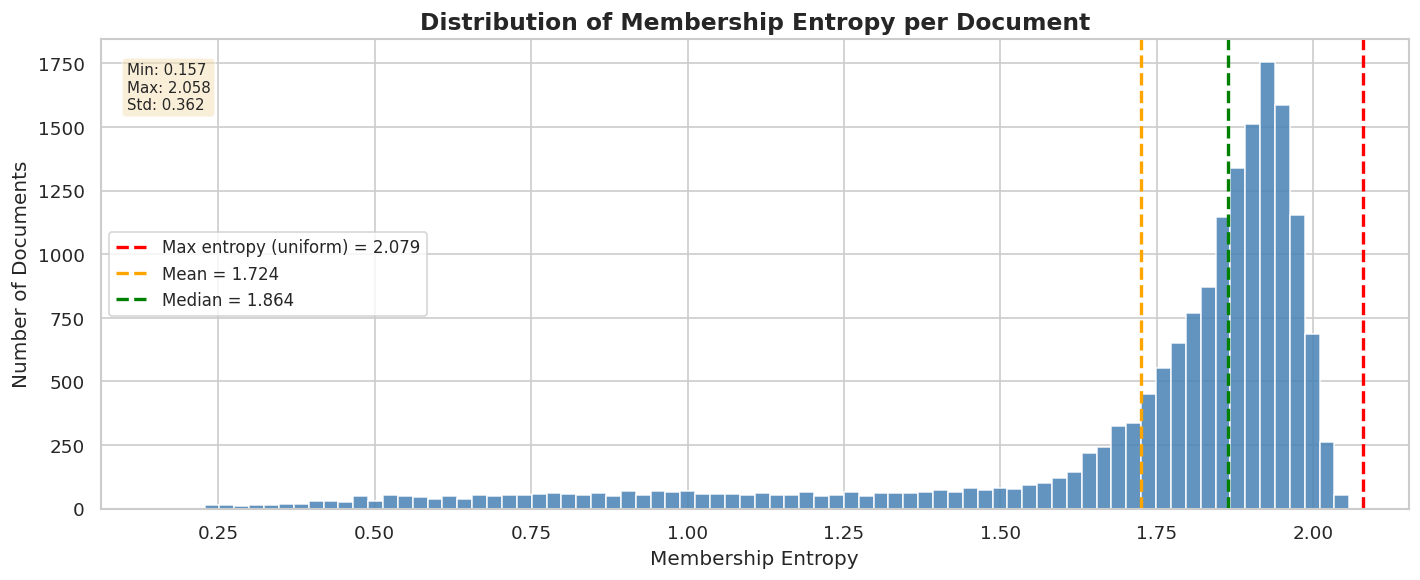

Saved to artefacts/clustering/entropy_histogram.png

Entropy stats:
  Mean:   1.7243
  Median: 1.8638
  Min:    0.1566 (crispest doc)
  Max:    2.0579 (most ambiguous)
  Uniform baseline: 2.0794


In [7]:
u_safe = np.clip(U, 1e-10, 1.0)
entropy = -np.sum(u_safe * np.log(u_safe), axis=1)
max_entropy = np.log(n_clusters)  # uniform = maximum entropy

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(entropy, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(max_entropy, color='red', linestyle='--', linewidth=2, label=f'Max entropy (uniform) = {max_entropy:.3f}')
ax.axvline(np.mean(entropy), color='orange', linestyle='--', linewidth=2, label=f'Mean = {np.mean(entropy):.3f}')
ax.axvline(np.median(entropy), color='green', linestyle='--', linewidth=2, label=f'Median = {np.median(entropy):.3f}')

ax.set_xlabel('Membership Entropy', fontsize=12)
ax.set_ylabel('Number of Documents', fontsize=12)
ax.set_title('Distribution of Membership Entropy per Document', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)

# Stats annotation
stats_text = f"Min: {entropy.min():.3f}\nMax: {entropy.max():.3f}\nStd: {entropy.std():.3f}"
ax.text(0.02, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(os.path.join(ARTEFACT_DIR, 'entropy_histogram.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to artefacts/clustering/entropy_histogram.png")
print(f"\nEntropy stats:")
print(f"  Mean:   {np.mean(entropy):.4f}")
print(f"  Median: {np.median(entropy):.4f}")
print(f"  Min:    {entropy.min():.4f} (crispest doc)")
print(f"  Max:    {entropy.max():.4f} (most ambiguous)")
print(f"  Uniform baseline: {max_entropy:.4f}")

## Summary

| Metric | Value |
|--------|-------|
| Clusters | 8 (selected by max PC) |
| Fuzzifier | m=1.2 |
| PCA dims | 50 (50.4% variance) |
| Partition Coefficient | 0.2443 (1.95× above 1/c) |
| Boundary docs (max_u < 0.2) | 32.7% of corpus |
| Crisp docs (max_u > 0.7) | 10.4% of corpus |